# (1) TITLE:            Calculating the global temporal averages of climate variables under SSP245, SAI-1.0, SAI-1.5.  
PROJECT:          "Climate analogs under SAI"  
AUTHORS:          Ruoyu Chen  
COLLABORATORS:    
DATA INPUT:       5 (06 to 10) ensemble files from climate variable folders (TSMX, PRECT, SST...) for each of SSP245, SAI-1.0, and SAI-1.5 scenarios.  
                   
DATA OUTPUT:      .nc file of the temporal and ensemble average over a selected period for climate variables (TSMX, PRECT, SST...) for the 3 climate scenarios. Saved in `"/mnt/research/nasabio/data/climate/L1/present"` for present period and `"/mnt/research/nasabio/data/climate/L1/future"` for future period.  
DATE:             Initiated: 5 June 2026; last run: July 21, 2026  
OVERVIEW:         Root path is: "/mnt/research/nasabio/data/climate/L1".   
REQUIRES:         So far 30 ensemble files: ensembles 006-010 from TSMX, PRECT, SST in SSP245, SAI-1.0, SAI-1.5 folders.  
NOTES:            Code file #1.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import xarray as xr
# Spatial subsetting of netcdf files
import regionmask
import glob

# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")


import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning
)

import earthpy as et

/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


## `create_avg_ncfile` ReadMe: 
This function takes ensemble members and takes the average of each dataset over a time frame, and then takes an average over all the ensembles. This function also automatically saves the output at the specified `output_path` and `file_name` as an .nc file.  
The parameters are: `members, start_year, end_year, input_path, unqiue_title, output_path, file_name`.  
* `members`: `list` of `Strings`. This is a list of the ensemble members you want to take the average of. Careful with inputs, because this is directly combined with the `input_path` and `unqiue_title` to get the full path to the ensemble members.
* `start_year`: `int`. The first year you want to include in your average.
* `end_year`: `int`. The last year you want to include in your average.
* `input_path`: `String` of the path from where you can access the ensemble files. 
* `unqiue_title`: `String` of the names of the ensemble files. This is included to get the file names of the ensembles. Make sure all your ensemble files start with this name to use the code.
* `output_path`: `String` path file to where you want to save the output file.
* `file_name`: `String` of the name of the .nc output file.  
  

Example code:  
```
members_no_008 = ['006', '007', '009', '010']
create_avg_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/present", "SSP245_PRECT.nc")
```
This slices each ensemble member from 2015 to 2034 and takes the average, and then takes another average of the ensembles '006', '007', '009', '010', and then saves it to `L1/present`.

In [2]:
#Function pulling everything together:

#input_path should be the full path to the .nc files. AND the specific file names for the members. 
def create_avg_ncfile(members, start_year, end_year, input_path, unqiue_title, output_path, file_name):
    path_files = []
    time_sliced_files = []
    # Get the list of all files and directories

    list_of_files = []
    for each in members:
        if (each.endswith("p95_threshold.nc")):
            list_of_files.remove(each)
        else: 
            path = input_path + "/" + unqiue_title + each + ".nc"
            file = xr.open_dataset(path)
            path_files.append(file)
    
    #For every ensemble, collapse the "year" dimension by averaging all values across the years at every lat and lon. 
    for each in path_files[:]: 
        sliced = each.sel(year = slice(start_year, end_year))
        each_ensemble_avg = sliced.mean(dim='year')
        time_sliced_files.append(each_ensemble_avg)

    # As a check of the code, let's look at if the first ensemble came out correctly. 
    # sliced1 = path_files[0].sel(year = slice(start_year, end_year)) #Data over the specified years. 
    # print(sliced1['CDD'].values[:, 2, 0]) #Here is the first value of the 3rd row for each of the 20 years. 
    # print((sliced1['CDD'].values[:, 2, 0]).mean()) #And it's mean. 
    # print(time_sliced_files[0]['CDD'].values[2, 0]) #And compare that with the 3rd row, 1st column of the averaged data. 
    
    concat_files_avg=xr.concat(time_sliced_files, dim='ensemble')
    concat_files_avg = concat_files_avg.assign_coords({'ensemble' : members})
    concat_files_avg = concat_files_avg.mean(dim='ensemble')

    concat_files_avg.attrs["title_description"] = concat_files_avg.attrs["scenario"] + " " + concat_files_avg.attrs["variable"] + " " + str(start_year) + "-" + str(end_year)
    
    concat_files_avg.to_netcdf(output_path + "/" + file_name)
    
    return concat_files_avg

### Creating averaged files  
This is implementing `create_avg_ncfile` to create temporal averages in present (2015-2034) and future (2050-2069) to create .nc files, and is saved in "/mnt/research/nasabio/data/climate/L1/present" for present period and "/mnt/research/nasabio/data/climate/L1/future" for future period. 

In [3]:
#Creating all future datasets 2050-2069

members = ['006', '007', '008', '009', '010']
members_no_008 = ['006', '007', '009', '010']

create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/future", "ARISE_SAI_1p5_PRECT.nc")
create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future", "ARISE_SAI_1p5_TSMX_extreme_high.nc")

create_avg_ncfile(members_no_008, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/future", "ARISE_SAI_1p0_PRECT.nc")
create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future", "ARISE_SAI_1p0_TSMX_extreme_high.nc")

create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/SSP245/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/future", "SSP245_PRECT.nc")
create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future", "SSP245_TSMX_extreme_high.nc")


# #Creating all present datasets in 2015-2034 for SSP245
create_avg_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/present", "SSP245_PRECT.nc")
create_avg_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/present", "SSP245_TSMX_extreme_high.nc")


<xarray.Dataset> Size: 2MB
Dimensions:         (lat: 192, lon: 288)
Coordinates:
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    annual_mean     (lat, lon) float32 221kB -46.48 -46.48 -46.48 ... nan nan
    frequency       (lat, lon) float64 442kB 5.68 5.68 5.68 5.68 ... nan nan nan
    duration        (lat, lon) float64 442kB 4.057 4.057 4.057 ... nan nan nan
    mean_intensity  (lat, lon) float32 221kB -36.89 -36.89 -36.89 ... nan nan
    max_intensity   (lat, lon) float32 221kB -21.67 -21.67 -21.67 ... nan nan
Attributes:
    scenario:               SSP245
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         SSP245 2015-2034
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9
    land_mask:              Natural Earth 110m
    threshold_method:       pooled individual members, linear detrend
    title_description:      SSP245 TSMX 2015-2034

## create_sliced_ncfile ReadMe
This gets the ensemble members, then for each of the ensemble members, slices it based on start and end year, and then gets the average of all the ensembles, creating one dataset that is the average of the ensembles sliced over the years. This is global data over many years. This is saved as a .nc file in "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged" and "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged".   
This is used later to make .csv files that are averaged based on every single year in the timeframe, using in "all_data_for_location" code file.   
Inputs are the same as `create_avg_ncfile`.

In [2]:

#input_path should be the full path to the .nc files. AND the specific file names for the members. 
def create_sliced_ncfile(members, start_year, end_year, input_path, unique_title, output_path, file_name):
    data_files = []
    time_sliced_files = []
    # Get the list of all files and directories

    list_of_files = []
    for each in members:
        if (each.endswith("p95_threshold.nc")):
            list_of_files.remove(each)
        else: 
            path = input_path + "/" + unique_title + each + ".nc"
            file = xr.open_dataset(path)
            data_files.append(file)
    
    for each in data_files[:]: 
        sliced = each.sel(year = slice(start_year, end_year))
        time_sliced_files.append(sliced)
    
    concat_files_avg= xr.concat(time_sliced_files, dim='ensemble')
    concat_files_avg = concat_files_avg.assign_coords({'ensemble' : members})
    concat_files_avg = concat_files_avg.mean(dim='ensemble')
    
    
    concat_files_avg.to_netcdf(output_path + "/" + file_name)
    
    return concat_files_avg

### Creating sliced avg files 
This code implements `create_sliced_ncfile`, saved as `.nc files`.   
The first cell gets the present period yearly data (globally) for ALL 4 available climate variables (TSMX, PRECT, O3, CONCLD).   
The second cell gets the future period yearly data (globally) for ONLY 2 climate variables (TSMX, PRECT). This was generated for MidSURE, so feel free to change.     


In [55]:
#Present period
members = ['006', '007', '008', '009', '010']
members_no8 = ['006', '007', '009', '010']

create_sliced_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged", "sliced_SSP245_TSMX.nc")
create_sliced_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged", "sliced_SSP245_PRECT.nc")
create_sliced_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/O3", "bioclim_indicators_", "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged", "sliced_SSP245_O3.nc")
create_sliced_ncfile(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/CONCLD", "bioclim_indicators_", "/mnt/research/nasabio/data/climate/L1/present/sliced_and_avged", "sliced_SSP245_CONCLD.nc")

<xarray.Dataset> Size: 21MB
Dimensions:      (year: 19, lat: 192, lon: 288)
Coordinates:
  * year         (year) int64 152B 2016 2017 2018 2019 ... 2031 2032 2033 2034
  * lat          (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon          (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    mean         (year, lat, lon) float32 4MB 0.0 0.0 ... 0.0001314 0.0001314
    max_month    (year, lat, lon) float32 4MB 0.0 0.0 0.0 ... 0.001124 0.001124
    min_month    (year, lat, lon) float32 4MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    range        (year, lat, lon) float32 4MB 0.0 0.0 0.0 ... 0.001124 0.001124
    seasonality  (year, lat, lon) float32 4MB nan nan nan ... 262.0 262.0 262.0
Attributes:
    scenario:                SSP245
    member:                  006
    variable:                CONCLD
    source_var:              CONCLD
    method:                  WorldClim-style monthly indicators (Hijmans et a...
    seasonality_definition:  100 * std(monthly, ddof=0) / mean(monthly)
    vertical_handling:       column_max
    unit_conversion:         value * 1.0 + 0.0

In [3]:
#Future period

#SSP24.5
create_sliced_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "sliced_SSP245_TSMX.nc")
create_sliced_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/SSP245/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "sliced_SSP245_PRECT.nc")

#SAI 1.0
create_sliced_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "sliced_ARISE_SAI_1p0_TSMX.nc")
create_sliced_ncfile(members_no8, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "sliced_ARISE_SAI_1p0_PRECT.nc")

#SAI 1.5
create_sliced_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "sliced_ARISE_SAI_1p5_TSMX.nc")
create_sliced_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/PRECT", "precip_indices_", "/mnt/research/nasabio/data/climate/L1/future/sliced_and_avged", "sliced_ARISE_SAI_1p5_PRECT.nc")


<xarray.Dataset> Size: 31MB
Dimensions:         (year: 20, lat: 192, lon: 288)
Coordinates:
  * year            (year) int64 160B 2015 2016 2017 2018 ... 2032 2033 2034
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    annual_mean     (year, lat, lon) float32 4MB -46.52 -46.52 ... nan nan
    frequency       (year, lat, lon) float64 9MB 6.0 6.0 6.0 6.0 ... nan nan nan
    duration        (year, lat, lon) float64 9MB 4.725 4.725 4.725 ... nan nan
    mean_intensity  (year, lat, lon) float32 4MB -35.23 -35.23 ... nan nan
    max_intensity   (year, lat, lon) float32 4MB -15.95 -15.95 ... nan nan
Attributes:
    scenario:               SSP245
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         SSP245 2015-2034
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9
    land_mask:              Natural Earth 110m
    threshold_method:       pooled individual members, linear detrend

# TESTING BELOW, IGNORE!

In [4]:
# So this function gets the standard deviation of the ensembles instead of the mean 
# The cells that produce the two graphs are supposed to be the standard deviation of the ensembles for the area
# It doesn't really make sense to map it out like that, but I didn't need this anyways. 

def get_stats_for_ensembles(members, start_year, end_year, input_path, unqiue_title):
    path_files = []
    time_sliced_files = []
    # Get the list of all files and directories

    list_of_files = []
    for each in members:
        if (each.endswith("p95_threshold.nc")):
            list_of_files.remove(each)
        else: 
            path = input_path + "/" + unqiue_title + each + ".nc"
            file = xr.open_dataset(path)
            path_files.append(file)
    
    #For every ensemble, collapse the "year" dimension by averaging all values across the years at every lat and lon. 
    for each in path_files[:]: 
        sliced = each.sel(year = slice(start_year, end_year))
        each_ensemble_avg = sliced.mean(dim='year')
        time_sliced_files.append(each_ensemble_avg)
        
    
    concat_files_avg=xr.concat(time_sliced_files, dim='ensemble')
    concat_files_avg = concat_files_avg.assign_coords({'ensemble' : members})
    
    concat_files_std = concat_files_avg.std(dim="ensemble")
    #GETS THE STANDARD DEVIATION OF ENSEMBLE MEMBERS instead of the mean. 
    
    #concat_files_avg = concat_files_avg.mean(dim='ensemble')
    # concat_files_avg.attrs["title_description"] = concat_files_avg.attrs["scenario"] + " " + concat_files_avg.attrs["variable"] + " " + str(start_year) + "-" + str(end_year)
    #concat_files_avg.to_netcdf(output_path + "/" + file_name)
    
    return concat_files_std

In [5]:
members = ['006', '007', '008', '009', '010']

present = get_stats_for_ensembles(members, 2015, 2034, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_")
SSP245 = get_stats_for_ensembles(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_")
SAI10 = get_stats_for_ensembles(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/TSMX/extreme_high", "extreme_indices_")
SAI15 = get_stats_for_ensembles(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/TSMX/extreme_high", "extreme_indices_")
#Gets the standard deviations for the members 

/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarnin

In [31]:
def convert_longitude(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    return ds
#expect shapefile in 5070. Time should be future or past.
#For simplicity, we are going to assume that the future and past data is stured in L1 folder, named 
#avg_past and avg_future. And that in this, it is the average of the data, globally
#and it is named in this format: climate_scenario + "_" + climate_variable + ".nc"

#Buffer recommend 300km or more. 
def get_location_data_all_pixels(netcdf, projection, *, target_lat = None, target_lon = None, shapefile = None, buffer = None):
    # climate_scenario = ["ARISE_SAI_1p0", "ARISE_SAI_1p5", "SSP245"]
    # climate_variables = ["SSP", "TSMX", "PRECT"]
    
    info_list = {}

    list_of_files = [netcdf]
    file_reprojected = []
    for each in list_of_files:
        file = convert_longitude(each)
        file = file.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        file.rio.write_crs("EPSG:4326", inplace=True) #Set our reference system (mercator projection)
        file = file.rio.reproject(projection)
        file_reprojected.append(file)
        
    
    if (target_lat != None and target_lon != None and shapefile == None):
        point = Point(target_lon, target_lat)
        gdf_point = gpd.GeoDataFrame(geometry=[point], crs="EPSG:4326")
        gdf_projected = gdf_point.to_crs(projection) #CONUS coordinate.
        
        
        masked_files_list = []        
        if (buffer != None):          #Buffered point
            buffered_geom = gdf_projected.geometry.buffer(buffer) #apply buffer.
            for each in file_reprojected:  
                masked_data = each.rio.clip(buffered_geom.geometry, drop = True, all_touched=True) #Set true if you want to crop it. 
                masked_files_list.append(masked_data)
                
            return masked_files_list
            
        
        else:           #No buffer point
            for each in file_reprojected:
                point_data = each.rio.clip(gdf_projected.geometry, drop = True, all_touched=True)
                #point_data = file_reprojected.sel(lat=target_lat, lon=target_lon, method='nearest')
                masked_files_list.append(point_data)
            return masked_files_list
                    
    elif (target_lat == None and target_lon == None):  #Shapefile        
        
        masked_files_list = []        
        for each in file_reprojected:            
            mask = shapefile.to_crs(each.rio.crs)
            sliced_masked = each.rio.clip(
                mask.geometry,
                mask.crs,
                drop=True,
                all_touched=True
            )
            
            masked_files_list.append(sliced_masked)
        return masked_files_list

    else: 
        return("Please enter either a point or a shapefile correctly.")
    #Checking for correct inputs. 

In [32]:
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
gl_p = get_location_data_all_pixels(present, "EPSG:5070", shapefile = great_lakes)
gl_ssp = get_location_data_all_pixels(SSP245, "EPSG:5070", shapefile = great_lakes)
gl_sai10 = get_location_data_all_pixels(SAI10, "EPSG:5070", shapefile = great_lakes)
gl_sai15 = get_location_data_all_pixels(SAI15, "EPSG:5070", shapefile = great_lakes)

# mid_atlantic = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]
# ma_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = mid_atlantic)

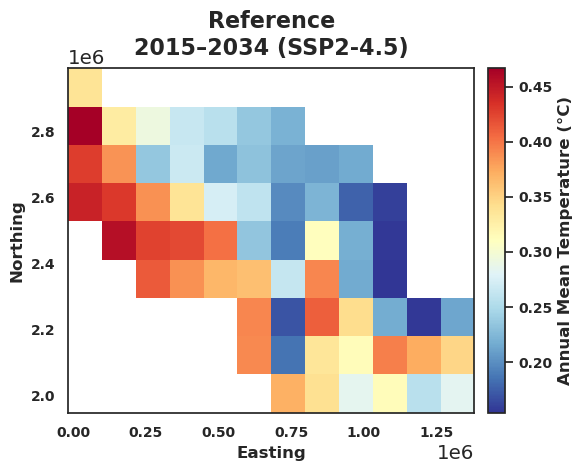

In [40]:

# Select reference annual mean temperature
reference = gl_p[0]["annual_mean"]

# Absolute minimum and maximum
ref_vmin = float(reference.min(skipna=True))
ref_vmax = float(reference.max(skipna=True))

fig, ax = plt.subplots(figsize=(6.1, 5))

ref_image = reference.plot(
    ax=ax,
    cmap="RdYlBu_r",
    vmin=ref_vmin,
    vmax=ref_vmax,
    add_colorbar=False
)

ax.set_title(
    "Reference\n2015–2034 (SSP2-4.5)",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax.set_xlabel(
    "Easting",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Northing",
    fontsize=12,
    fontweight="bold"
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

ref_cbar = fig.colorbar(
    ref_image,
    ax=ax,
    fraction=0.046,
    pad=0.03
)

ref_cbar.set_label(
    "Annual Mean Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in ref_cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.tight_layout()
plt.show()

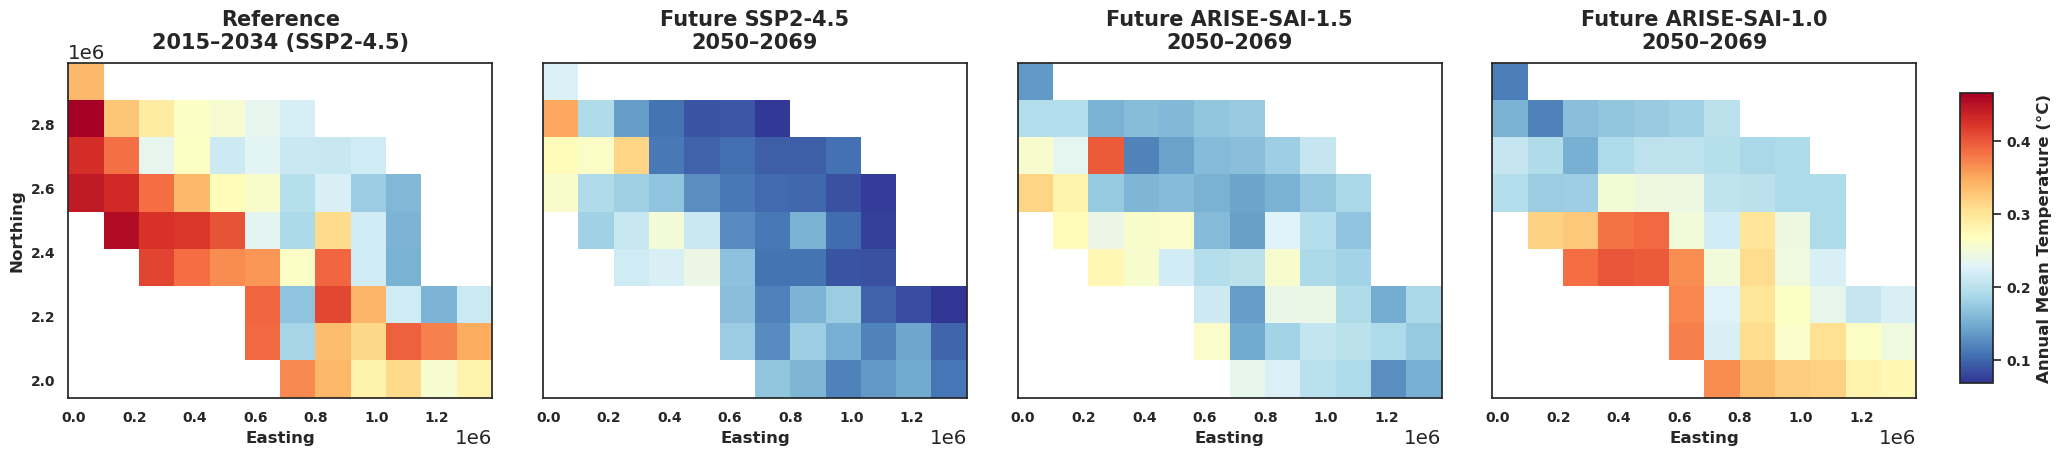

In [45]:
import matplotlib.pyplot as plt

# Select annual mean temperature from each dataset
reference = gl_p[0]["annual_mean"]
ssp245 = gl_ssp[0]["annual_mean"]
sai15 = gl_sai15[0]["annual_mean"]
sai10 = gl_sai10[0]["annual_mean"]

data = [
    reference,
    ssp245,
    sai15,
    sai10
]

titles = [
    "Reference\n2015–2034 (SSP2-4.5)",
    "Future SSP2-4.5\n2050–2069",
    "Future ARISE-SAI-1.5\n2050–2069",
    "Future ARISE-SAI-1.0\n2050–2069"
]

# Shared absolute min/max across all 4 graphs
vmin = min(float(d.min(skipna=True)) for d in data)
vmax = max(float(d.max(skipna=True)) for d in data)

fig, axs = plt.subplots(
    1,
    4,
    figsize=(22, 5),
    sharex=True,
    sharey=True
)

for ax, d, title in zip(axs, data, titles):
    image = d.plot(
        ax=ax,
        cmap="RdYlBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Easting",
        fontsize=12,
        fontweight="bold"
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(10)

# Only show y-axis label on first subplot
axs[0].set_ylabel(
    "Northing",
    fontsize=12,
    fontweight="bold"
)

for ax in axs[1:]:
    ax.set_ylabel("")

# Adjust spacing and leave room for one shared colorbar
fig.subplots_adjust(
    left=0.06,
    right=0.90,
    bottom=0.15,
    top=0.82,
    wspace=0.12
)

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.58])

cbar = fig.colorbar(
    image,
    cax=cbar_ax
)

cbar.set_label(
    "Annual Mean Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.show()

In [37]:
#Used for testing.

climate_scenario = "ARISE_SAI_1p5"
climate_variable = "TSMX"
start_year = 2035
end_year = 2040

path_files = []
time_sliced_files = []


input_path = "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p5/TSMX/extreme_high"
unqiue_title = 	"extreme_indices_"

members = ['006', '007', '008', '009', '010']
for each in members:
    if (each.endswith("p95_threshold.nc")):
        list_of_files.remove(each)
    else: 
        path = input_path + "/" + unqiue_title + each + ".nc"
        file = xr.open_dataset(path)
        path_files.append(file)

time_sliced_files = []
for each in path_files[:]: 
    sliced = each.sel(year = slice(start_year, end_year))
    time_sliced_files.append(sliced)

members = ['006', '007', '008', '009', '010']
concat_files_avg= xr.concat(time_sliced_files, dim='ensemble')
concat_files_avg = concat_files_avg.assign_coords({'ensemble' : members})
concat_files_avg = concat_files_avg.mean(dim='ensemble')

yearly_list = []
for year in range(start_year, end_year + 1):
    sliced = concat_files_avg.sel(year = slice(year, year)).copy()
    sliced = sliced.squeeze(dim = "year")
    y = str(year)
    sliced.attrs["title_description"] = sliced.attrs["scenario"] + " " + sliced.attrs["variable"] + " " + y
    yearly_list.append(sliced)             #Add each file to time_sliced_files. 

print(yearly_list)



concat_files_avg

#.concat first stacks all ensembles along a new dimension, ensemble. 
#.mean then takes the average of all the values along that new dimension, and collapses the ensemble dimension. 

# x = concat_files_avg["annual_mean"]
# x.plot()



#save_path = "/mnt/research/nasabio/data/climate/L1/" + climate_scenario + "/ensemble_avg/"
#file_name = "testing_example_temp1.nc"

save_path = "/mnt/home/f0113797/Documents/testing.nc"

# # #file_name = "EXAMPLE_" + climate_scenario + "_avg_" + climate_variable + "_values_" + str(start_year) + "-" + str(end_year)+ ".nc"
concat_files_avg.to_netcdf(save_path)

concat_files_avg

# return concat_files_avg




[<xarray.Dataset> Size: 2MB
Dimensions:         (lat: 192, lon: 288)
Coordinates:
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
    year            int64 8B 2035
Data variables:
    annual_mean     (lat, lon) float32 221kB -45.62 -45.62 -45.62 ... nan nan
    frequency       (lat, lon) float64 442kB 7.8 7.8 7.8 7.8 ... nan nan nan nan
    duration        (lat, lon) float64 442kB 4.484 4.484 4.484 ... nan nan nan
    mean_intensity  (lat, lon) float32 221kB -32.53 -32.53 -32.53 ... nan nan
    max_intensity   (lat, lon) float32 221kB -15.86 -15.86 -15.86 ... nan nan
Attributes:
    scenario:               ARISE_SAI_1p5
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         ARISE_SAI_1p5 TSMX 2035
    consec_days_threshold:  3
    extreme_direction:      above
    qu

<xarray.Dataset> Size: 9MB
Dimensions:         (year: 6, lat: 192, lon: 288)
Coordinates:
  * year            (year) int64 48B 2035 2036 2037 2038 2039 2040
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    annual_mean     (year, lat, lon) float32 1MB -45.62 -45.62 ... nan nan
    frequency       (year, lat, lon) float64 3MB 7.8 7.8 7.8 7.8 ... nan nan nan
    duration        (year, lat, lon) float64 3MB 4.484 4.484 4.484 ... nan nan
    mean_intensity  (year, lat, lon) float32 1MB -32.53 -32.53 ... nan nan
    max_intensity   (year, lat, lon) float32 1MB -15.86 -15.86 ... nan nan
Attributes:
    scenario:               ARISE_SAI_1p5
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         SSP245 2015-2034
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9
    land_mask:              Natural Earth 110m
    threshold_method:       pooled individual members, linear detrend

In [22]:
y1 = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high/extreme_indices_010.nc")
z1 = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/TSMX/extreme_high/extreme_indices_010.nc")

print(y1.attrs["clim_reference"])
print(z1.attrs["clim_reference"])



y = create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/SSP245/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future", "TEST_SSP245_TSMX_extreme_high.nc")
z = create_avg_ncfile(members, 2050, 2069, "/mnt/research/nasabio/data/climate/L1/ARISE_SAI_1p0/TSMX/extreme_high", "extreme_indices_", "/mnt/research/nasabio/data/climate/L1/future", "TEST_ARISE_SAI_1p0_TSMX_extreme_high.nc")

SSP245 2015-2034
SSP245 2015-2034


In [16]:
y

<xarray.Dataset> Size: 2MB
Dimensions:         (lat: 192, lon: 288)
Coordinates:
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    annual_mean     (lat, lon) float32 221kB -44.62 -44.62 -44.62 ... nan nan
    frequency       (lat, lon) float64 442kB 9.32 9.32 9.32 9.32 ... nan nan nan
    duration        (lat, lon) float64 442kB 4.6 4.6 4.6 4.6 ... nan nan nan nan
    mean_intensity  (lat, lon) float32 221kB -34.57 -34.57 -34.57 ... nan nan
    max_intensity   (lat, lon) float32 221kB -16.35 -16.35 -16.35 ... nan nan
Attributes:
    scenario:               SSP245
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         SSP245 TSMX 2050-2069
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9
    land_mask:              Natural Earth 110m
    threshold_method:       pooled individual members, linear detrend

In [17]:
z

<xarray.Dataset> Size: 2MB
Dimensions:         (lat: 192, lon: 288)
Coordinates:
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    annual_mean     (lat, lon) float32 221kB -46.85 -46.85 -46.85 ... nan nan
    frequency       (lat, lon) float64 442kB 4.56 4.56 4.56 4.56 ... nan nan nan
    duration        (lat, lon) float64 442kB 4.261 4.261 4.259 ... nan nan nan
    mean_intensity  (lat, lon) float32 221kB -39.57 -39.57 -39.58 ... nan nan
    max_intensity   (lat, lon) float32 221kB -27.94 -27.94 -27.94 ... nan nan
Attributes:
    scenario:               ARISE_SAI_1p0
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         ARISE_SAI_1p0 TSMX 2050-2069
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9
    land_mask:              Natural Earth 110m
    threshold_method:       pooled individual members, linear detrend